# ME-XBAL — Tokopedia / PRDECT-ID (Revised Pipeline)

Notebook ini menerapkan **protokol yang sama persis** dengan `semeval-dataset_v3.ipynb` pada dataset
Tokopedia. Jalankan sel dari atas ke bawah.

Menutup komentar reviewer berikut untuk sisi Tokopedia:

| Komentar | Cara ditutup |
|---|---|
| R1 #5 — Macro F1 abstract 0.5569 vs Tabel 5 0.5821 | Semua tabel dihasilkan satu skrip; angka final hanya ada satu sumber |
| R1 #6 — distribusi kelas tidak konsisten dengan ukuran train | Tabel distribusi memisahkan **seluruh dataset** dan **partisi train** secara eksplisit |
| R1 #8 — klaim efisiensi Tokopedia | Timing dipisah per boundary: embedding, preprocessing, training, kalibrasi, inference, SHAP |
| R2 #3 — kebocoran validasi | Split tiga arah immutable; scaler, PCA, class weight, bobot ensemble, dan kalibrasi kelas semuanya di-fit di train/validation |
| R2 #5 — reproduktibilitas | UID stabil, manifest partisi tiap seed, tabel konfigurasi lengkap |
| R2 #6 — ablasi tidak terkontrol | Rantai A0→A6 satu faktor + branch leave-one-out A2b/A2c + tabel dekomposisi |
| R2 #7 — variansi & signifikansi | 10 seed, mean ± std, 95% CI, Wilcoxon berpasangan |

**Perbedaan dengan SemEval.** PRDECT-ID bersifat **single-label 5 kelas**, bukan multi-label. Analog
dari *threshold optimization* di sini adalah **kalibrasi prior kelas**: probabilitas tiap kelas
dikalikan faktor α yang dicari di validation, lalu diambil argmax. Pengaman anti-degeneratif yang
sama diterapkan — α dibatasi rentangnya dan seri diputus ke arah α = 1 (tanpa penyesuaian).

## 1. Konfigurasi & impor

In [2]:
# ============================================================
# KONFIGURASI GLOBAL
# ============================================================
import os, sys, re, glob, time, json, random, subprocess, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             accuracy_score, confusion_matrix, classification_report)
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from scipy import stats
import xgboost as xgb
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# PATH — sesuaikan bila lokasi dataset berbeda
# ------------------------------------------------------------
TOKOPEDIA_CSV = "/kaggle/input/datasets/jocelyndumlao/prdect-id-indonesian-emotion-classification/Product Reviews Dataset for Emotions Classification Tasks - Indonesian (PRDECT-ID) Dataset/PRDECT-ID Dataset.csv"
OUT_DIR   = "/kaggle/working/outputs"
FIG_DIR   = os.path.join(OUT_DIR, "figures")
SPLIT_DIR = os.path.join(OUT_DIR, "splits")
CACHE_DIR = os.path.join(OUT_DIR, "cache")
for d in (OUT_DIR, FIG_DIR, SPLIT_DIR, CACHE_DIR):
    os.makedirs(d, exist_ok=True)

TEXT_COL, LABEL_COL = "Customer Review", "Emotion"

# ------------------------------------------------------------
# PROTOKOL EKSPERIMEN — identik dengan notebook SemEval
# ------------------------------------------------------------
SEEDS        = [42, 7, 13, 77, 101, 202, 303, 404, 505, 606]
SEED_PRIMARY = 42
VAL_FRAC     = 0.15
TEST_FRAC    = 0.20

# ------------------------------------------------------------
# ENCODER
# ------------------------------------------------------------
XLMR_NAME     = "xlm-roberta-base"
INDOBERT_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN       = 128
BATCH_SIZE    = 32
POOLING       = "masked_mean"

# ------------------------------------------------------------
# ANALISIS TAMBAHAN
# ------------------------------------------------------------
RUN_ABLATION   = True
RUN_FAITHFUL   = True
RUN_TIMING     = True
RUN_FINETUNE   = True
FT_SEEDS       = SEEDS        # dengan 3 seed, p minimum Wilcoxon = 0.25
FT_MAX_EPOCHS  = 8            # early stopping menurunkan variansi fine-tuning
FT_PATIENCE    = 3
N_FAITHFUL     = 30
SHAP_MAX_EVALS = 300

# ------------------------------------------------------------
# HYPERPARAMETER
# ------------------------------------------------------------
XGB_PARAMS = dict(
    max_depth=3, min_child_weight=5, learning_rate=0.05, n_estimators=200,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.5,
    objective="multi:softprob", eval_metric="mlogloss", verbosity=0, n_jobs=-1,
)

# Kalibrasi prior kelas — analog threshold optimization untuk kasus single-label.
# Rentang dibatasi dan seri diputus ke arah alpha=1 agar tidak muncul solusi
# degeneratif yang mendorong semua prediksi ke satu kelas minoritas.
ALPHA_MIN, ALPHA_MAX, ALPHA_STEP = 0.50, 3.00, 0.05
ALPHA_GRID   = np.arange(ALPHA_MIN, ALPHA_MAX + 1e-9, ALPHA_STEP)
ALPHA_PASSES = 3
TIE_TOLERANCE = 0.005

W_GRID = np.arange(0.0, 1.0001, 0.05)      # grid bobot ensemble

# ------------------------------------------------------------
# NESTED CROSS-VALIDATION untuk bobot ensemble dan kalibrasi kelas.
# Bobot dan alpha dipilih dari probabilitas out-of-fold atas SELURUH development
# set (train + validation), bukan dari satu validation split. Test set tetap
# tidak pernah disentuh. Ini "nested cross-validation" yang diminta Reviewer 2 #3,
# dan protokolnya identik dengan notebook SemEval agar kedua dataset sebanding.
# ------------------------------------------------------------
USE_NESTED_CV   = True
NESTED_CV_FOLDS = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

plt.rcParams.update({"font.size": 11, "savefig.dpi": 600, "figure.dpi": 110})

def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=600, bbox_inches="tight")
    fig.savefig(os.path.join(FIG_DIR, name + ".pdf"), format="pdf", bbox_inches="tight")

print("Device        :", device)
print("Seeds         :", SEEDS)
print(f"Split fraction: train {1-VAL_FRAC-TEST_FRAC:.2f} / val {VAL_FRAC:.2f} / test {TEST_FRAC:.2f}")
print(f"Alpha grid    : [{ALPHA_MIN:.2f}, {ALPHA_MAX:.2f}] step {ALPHA_STEP:.2f}, {ALPHA_PASSES} pass")

Device        : cuda
Seeds         : [42, 7, 13, 77, 101, 202, 303, 404, 505, 606]
Split fraction: train 0.65 / val 0.15 / test 0.20
Alpha grid    : [0.50, 3.00] step 0.05, 3 pass


## 2. Data, UID stabil, dan split tiga arah

Bagian ini juga menghasilkan tabel distribusi kelas yang **memisahkan seluruh dataset dari partisi
train**. Reviewer 1 #6 menemukan bahwa manuskrip menyebut training set berisi 4.320 review tetapi
mencantumkan hitungan kelas yang berjumlah 5.400 — yaitu ukuran seluruh dataset. Tabel di bawah
mencetak keduanya berdampingan sehingga angka yang disalin ke manuskrip tidak mungkin tertukar.

In [3]:
# ============================================================
# LOAD DATA + UID STABIL
# ============================================================
if not os.path.exists(TOKOPEDIA_CSV):
    cands = glob.glob("/content/drive/MyDrive/**/*PRDECT*.csv", recursive=True)
    assert cands, (f"Dataset tidak ditemukan di {TOKOPEDIA_CSV}. "
                   "Sesuaikan TOKOPEDIA_CSV di sel konfigurasi.")
    TOKOPEDIA_CSV = cands[0]
    print("Memakai file yang ditemukan otomatis:", TOKOPEDIA_CSV)

df = pd.read_csv(TOKOPEDIA_CSV)
df = df[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)
df[TEXT_COL] = df[TEXT_COL].astype(str)

le = LabelEncoder()
df["label"] = le.fit_transform(df[LABEL_COL])
CLASSES = list(le.classes_)
N_CLASSES = len(CLASSES)
df["uid"] = [f"tok_{i:05d}" for i in range(len(df))]

y_all = df["label"].values
print(f"Dataset  : {len(df)} review, {N_CLASSES} kelas -> {CLASSES}")


# ============================================================
# SPLIT TIGA ARAH (stratified, single-label)
# ============================================================
def stratified_split(y, test_size, seed):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    a, b = next(sss.split(np.zeros(len(y)), y))
    return np.sort(a), np.sort(b)


def three_way_split(y, seed, val_frac=VAL_FRAC, test_frac=TEST_FRAC):
    hold_frac = val_frac + test_frac
    idx_train, idx_hold = stratified_split(y, hold_frac, seed)
    sub_val, sub_test = stratified_split(y[idx_hold], test_frac / hold_frac, seed)
    return idx_train, idx_hold[sub_val], idx_hold[sub_test]


SPLITS, rows = {}, []
for seed in SEEDS:
    tr, va, te = three_way_split(y_all, seed)
    SPLITS[seed] = (tr, va, te)
    n = len(df)
    assert len(set(tr) & set(va)) == 0 and len(set(tr) & set(te)) == 0 \
           and len(set(va) & set(te)) == 0, f"seed {seed}: partisi tumpang tindih"
    assert len(tr) + len(va) + len(te) == n, f"seed {seed}: ada sampel hilang"
    assert abs(len(te)/n - TEST_FRAC) < 0.02, f"seed {seed}: test frac {len(te)/n:.3f}"
    assert abs(len(va)/n - VAL_FRAC) < 0.02, f"seed {seed}: val frac {len(va)/n:.3f}"
    for name, idx in [("train", tr), ("val", va), ("test", te)]:
        for u in df["uid"].values[idx]:
            rows.append({"seed": seed, "split": name, "uid": u})

split_manifest = pd.DataFrame(rows)
split_manifest.to_csv(os.path.join(SPLIT_DIR, "split_manifest_all_seeds.csv"), index=False)

tr, va, te = SPLITS[SEED_PRIMARY]
print(f"\nSplit (seed={SEED_PRIMARY}): train {len(tr)} / val {len(va)} / test {len(te)}  "
      f"-> {len(tr)/len(df):.2f} / {len(va)/len(df):.2f} / {len(te)/len(df):.2f}")
print("Semua assertion proporsi split LULUS.")


# ============================================================
# DISTRIBUSI KELAS — MEMISAHKAN SELURUH DATASET DAN PARTISI TRAIN
# Ini yang memperbaiki R1 #6 secara langsung.
# ============================================================
dist = pd.DataFrame({
    "Emotion": CLASSES,
    "Entire dataset": [int((y_all == i).sum()) for i in range(N_CLASSES)],
    "Train split": [int((y_all[tr] == i).sum()) for i in range(N_CLASSES)],
    "Validation split": [int((y_all[va] == i).sum()) for i in range(N_CLASSES)],
    "Test split": [int((y_all[te] == i).sum()) for i in range(N_CLASSES)],
})
dist.loc[len(dist)] = ["TOTAL", dist["Entire dataset"].sum(), dist["Train split"].sum(),
                       dist["Validation split"].sum(), dist["Test split"].sum()]

print("\n" + "=" * 76)
print(f"TABEL 1 — DISTRIBUSI KELAS (seed={SEED_PRIMARY})")
print("=" * 76)
print(dist.to_string(index=False))
print("\nPERHATIAN untuk manuskrip: kolom 'Entire dataset' dan 'Train split' adalah dua hal")
print("berbeda. Versi lama menyebut angka kolom pertama sebagai distribusi training set —")
print("itulah inkonsistensi yang dilaporkan Reviewer 1 #6. Salin dari kolom yang tepat.")

dist.to_csv(os.path.join(OUT_DIR, "table1_class_distribution.csv"), index=False)

# ============================================================
# EKSPOR UKURAN PARTISI LINTAS SEED
# ============================================================
rows_sz = [{"seed": sd, "total": len(df),
            "train": len(SPLITS[sd][0]), "validation": len(SPLITS[sd][1]),
            "test": len(SPLITS[sd][2])} for sd in SEEDS]
pd.DataFrame(rows_sz).to_csv(os.path.join(OUT_DIR, "table_split_sizes_all_seeds.csv"),
                             index=False)
print("\nUkuran partisi lintas seed disimpan: table_split_sizes_all_seeds.csv")


Dataset  : 5400 review, 5 kelas -> ['Anger', 'Fear', 'Happy', 'Love', 'Sadness']

Split (seed=42): train 3510 / val 809 / test 1081  -> 0.65 / 0.15 / 0.20
Semua assertion proporsi split LULUS.

TABEL 1 — DISTRIBUSI KELAS (seed=42)
Emotion  Entire dataset  Train split  Validation split  Test split
  Anger             699          454               105         140
   Fear             920          598               138         184
  Happy            1770         1151               265         354
   Love             809          526               121         162
Sadness            1202          781               180         241
  TOTAL            5400         3510               809        1081

PERHATIAN untuk manuskrip: kolom 'Entire dataset' dan 'Train split' adalah dua hal
berbeda. Versi lama menyebut angka kolom pertama sebagai distribusi training set —
itulah inkonsistensi yang dilaporkan Reviewer 1 #6. Salin dari kolom yang tepat.

Ukuran partisi lintas seed disimpan: table_split_si

## 3. Ekstraksi embedding (sekali untuk seluruh dataset)

Encoder di-*freeze*, embedding di-*cache*, masked mean pooling untuk XLM-R maupun IndoBERT.
Karena tidak ada label yang terlibat, mengekstrak sekali lalu mengiris per split tidak menimbulkan
kebocoran — dan inilah yang membuat 10 seed murah.

In [4]:
# ============================================================
# EKSTRAKSI EMBEDDING — SEKALI, LALU DI-CACHE
# ============================================================
def load_encoder(name):
    tok = AutoTokenizer.from_pretrained(name)
    mod = AutoModel.from_pretrained(name).to(device).eval()
    return tok, mod


@torch.no_grad()
def encode_texts(texts, tok, mod, batch_size=BATCH_SIZE, max_length=MAX_LEN, desc="encoding"):
    out = []
    for i in tqdm(range(0, len(texts), batch_size), desc=desc, leave=False):
        batch = [str(t) for t in texts[i:i + batch_size]]
        enc = tok(batch, padding=True, truncation=True,
                  max_length=max_length, return_tensors="pt").to(device)
        h = mod(**enc).last_hidden_state
        m = enc["attention_mask"].unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1).clamp(min=1e-9)).cpu().numpy())
    return np.vstack(out)


ENCODERS = {"xlmr": XLMR_NAME, "indo": INDOBERT_NAME}
EMB = {}
texts_all = df[TEXT_COL].tolist()

for key, name in ENCODERS.items():
    cache = os.path.join(CACHE_DIR, f"emb_{key}.npy")
    if os.path.exists(cache):
        EMB[key] = np.load(cache)
        print(f"[{key}] embedding dimuat dari cache")
    else:
        print(f"[{key}] memuat encoder {name} ...")
        tok, mod = load_encoder(name)
        EMB[key] = encode_texts(texts_all, tok, mod, desc=f"{key}")
        np.save(cache, EMB[key])
        print(f"[{key}] embedding disimpan ke {cache}")
        if key != "xlmr":
            del mod; torch.cuda.empty_cache()

xlmr_tok, xlmr_mod = load_encoder(XLMR_NAME)

for key in EMB:
    assert EMB[key].shape[0] == len(df), f"{key}: jumlah baris tidak cocok"
    print(f"{key:<6} shape = {EMB[key].shape}")

[xlmr] memuat encoder xlm-roberta-base ...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

indo:   0%|          | 0/169 [00:00<?, ?it/s]

[indo] embedding disimpan ke /kaggle/working/outputs/cache/emb_indo.npy


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


xlmr   shape = (5400, 768)
indo   shape = (5400, 768)


## 4. Fungsi inti pipeline

Satu fungsi `run_variant()` menangani ME-XBAL, seluruh baseline, dan seluruh baris ablasi — sehingga
tidak ada jalur kode terpisah yang diam-diam memakai hyperparameter berbeda. Itulah penyebab ablasi
versi lama tidak bisa diinterpretasikan (Reviewer 2 #6).

**Kalibrasi prior kelas** adalah analog *threshold optimization* untuk kasus single-label. Setiap
kelas mendapat faktor α, probabilitas dikalikan α, lalu diambil argmax. α dicari dengan coordinate
ascent **di validation saja**, dengan dua pengaman: rentang dibatasi ke [0.50, 3.00], dan bila
beberapa nilai α memberi Macro F1 yang praktis sama, dipilih yang **paling dekat ke 1.0** — yaitu
yang paling sedikit mengintervensi. Tanpa pengaman ini, pencarian cenderung mendorong prediksi ke
kelas minoritas demi menaikkan Macro F1 secara artifisial.

In [5]:
# ============================================================
# FUNGSI INTI
# ============================================================
def build_preprocessor(X_train, scale, do_pca, seed):
    """Fit scaler/PCA HANYA pada train; kembalikan fungsi transform."""
    sc = StandardScaler().fit(X_train) if scale else None
    Z = sc.transform(X_train) if sc is not None else X_train
    pca = PCA(n_components=0.95, random_state=seed).fit(Z) if do_pca else None

    def transform(X):
        Z = sc.transform(X) if sc is not None else X
        return pca.transform(Z) if pca is not None else Z

    return transform, sc, pca


def train_classifiers(X_tr, y_tr, cfg, seed):
    xgb_model = lr_model = None
    if cfg["use_xgb"]:
        m = xgb.XGBClassifier(num_class=N_CLASSES, random_state=seed, **XGB_PARAMS)
        sw = compute_sample_weight("balanced", y_tr) if cfg["cost_sensitive"] else None
        m.fit(X_tr, y_tr, sample_weight=sw)
        xgb_model = m
    if cfg["use_lr"]:
        lr_model = LogisticRegression(
            C=cfg["lr_C"], penalty="l2", max_iter=1000, solver="lbfgs", random_state=seed,
            class_weight=("balanced" if cfg["lr_balanced"] else None)).fit(X_tr, y_tr)
    return xgb_model, lr_model


def blend(px, pl, w):
    if px is None:
        return pl
    if pl is None:
        return px
    return w * px + (1.0 - w) * pl


def tune_weight(px_val, pl_val, y_val, grid=W_GRID):
    """Bobot ensemble dicari DI VALIDATION. Test tidak dilihat."""
    best_w, best_f1 = 0.5, -1.0
    for w in grid:
        f1 = f1_score(y_val, np.argmax(blend(px_val, pl_val, w), axis=1),
                      average="macro", zero_division=0)
        if f1 > best_f1 + 1e-12:
            best_f1, best_w = f1, float(w)
    return best_w


def tune_alpha(proba_val, y_val, grid=ALPHA_GRID, passes=ALPHA_PASSES, tie_tol=TIE_TOLERANCE):
    """Kalibrasi prior kelas via coordinate ascent DI VALIDATION.

    Seri diputus ke arah alpha = 1.0 (intervensi paling kecil), sehingga
    kalibrasi tidak menghasilkan solusi degeneratif yang mendorong prediksi
    ke satu kelas minoritas hanya demi menaikkan Macro F1.
    """
    alpha = np.ones(N_CLASSES)
    for _ in range(passes):
        for c in range(N_CLASSES):
            scores = []
            for a in grid:
                trial = alpha.copy(); trial[c] = a
                scores.append(f1_score(y_val, np.argmax(proba_val * trial, axis=1),
                                       average="macro", zero_division=0))
            scores = np.asarray(scores)
            near = np.where(scores >= scores.max() - tie_tol)[0]
            alpha[c] = float(grid[near[np.argmin(np.abs(grid[near] - 1.0))]])
    return alpha


# ------------------------------------------------------------
# KONFIGURASI VARIAN
# ------------------------------------------------------------
def make_cfg(name, encoder="xlmr", scale=True, do_pca=True, use_xgb=True, use_lr=True,
             cost_sensitive=True, lr_balanced=True, lr_C=0.1, w_xgb=0.5, tune_w=True,
             calibrate=True):
    return dict(name=name, encoder=encoder, scale=scale, do_pca=do_pca,
                use_xgb=use_xgb, use_lr=use_lr, cost_sensitive=cost_sensitive,
                lr_balanced=lr_balanced, lr_C=lr_C, w_xgb=w_xgb, tune_w=tune_w,
                calibrate=calibrate)


BASE = dict(cost_sensitive=False, lr_balanced=False, lr_C=1.0, w_xgb=0.5, tune_w=False)

# ------------------------------------------------------------
# METODE YANG DIUSULKAN = ENSEMBLE PENUH (XGBoost + Logistic Regression).
#
# Keputusan ini diambil setelah hasil sepuluh seed pada KEDUA dataset tersedia.
# Kontribusi XGBoost konsisten positif tetapi tidak signifikan pada uji
# leave-one-out (SemEval p = 0.065; Tokopedia p = 0.105), sementara kontribusi
# Logistic Regression signifikan pada keduanya. XGBoost tetap dipertahankan
# karena arah efeknya replikatif lintas dataset dengan tipe tugas berbeda dan
# karena keunggulannya terkonsentrasi pada subset terkecil dan paling timpang.
# Klaim signifikansi TIDAK dibuat untuk komponen ini di manuskrip.
#
# Varian tanpa XGBoost tetap dievaluasi penuh dan dilaporkan sebagai
# konfigurasi kelas satu (training ~2.5x lebih cepat, skor tak terbedakan
# secara statistik), sehingga pembaca dapat memilih trade-off-nya sendiri.
# ------------------------------------------------------------
VARIANTS = [
    make_cfg("ME-XBAL", use_xgb=False),                                      # varian ringan
    make_cfg("ME-XBAL+XGB", use_xgb=True, use_lr=True, tune_w=True),         # METODE YANG DIUSULKAN
    make_cfg("XLM-R Hybrid",    encoder="xlmr", **BASE),
    make_cfg("XLM-R LR",        encoder="xlmr", use_xgb=False, **BASE),
    make_cfg("XLM-R XGB",       encoder="xlmr", use_lr=False,  **BASE),
    make_cfg("IndoBERT LR",     encoder="indo", use_xgb=False, **BASE),
    make_cfg("IndoBERT XGB",    encoder="indo", use_lr=False,  **BASE),
    make_cfg("IndoBERT Hybrid", encoder="indo", **BASE),
]
VARIANT_ORDER = [c["name"] for c in VARIANTS]


def oof_probabilities(X_dev, y_dev, cfg, seed, n_folds=NESTED_CV_FOLDS):
    """Probabilitas out-of-fold atas development set (inner loop dari nested CV).

    Setiap fold: scaler, PCA, class weight, dan klasifier di-fit ULANG hanya pada
    K-1 fold, lalu dipakai memprediksi fold yang ditahan. Bobot ensemble dan
    kalibrasi alpha yang dicari dari matriks ini karena itu bebas kebocoran.
    Dikembalikan terpisah agar bobot ensemble tetap bisa dicari.
    """
    n = X_dev.shape[0]
    oof_px = np.zeros((n, N_CLASSES)) if cfg["use_xgb"] else None
    oof_pl = np.zeros((n, N_CLASSES)) if cfg["use_lr"] else None
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    for fold_tr, fold_va in skf.split(np.zeros(n), y_dev):
        tf, _, _ = build_preprocessor(X_dev[fold_tr], cfg["scale"], cfg["do_pca"], seed)
        xm, lm = train_classifiers(tf(X_dev[fold_tr]), y_dev[fold_tr], cfg, seed)
        Z = tf(X_dev[fold_va])
        if cfg["use_xgb"]:
            oof_px[fold_va] = xm.predict_proba(Z)
        if cfg["use_lr"]:
            oof_pl[fold_va] = lm.predict_proba(Z)
    return oof_px, oof_pl


def run_variant(cfg, seed, return_artifacts=False):
    set_seed(seed)
    X = EMB[cfg["encoder"]]
    tr, va, te = SPLITS[seed]

    # Development = train + validation. Bobot dan alpha dicari dari OOF di sini;
    # model final dilatih ulang pada seluruh development. Test tidak disentuh.
    dev = np.concatenate([tr, va])
    y_dev = y_all[dev]

    if USE_NESTED_CV:
        px_sel, pl_sel = oof_probabilities(X[dev], y_dev, cfg, seed)
        y_sel = y_dev
    else:
        tf_tmp, _, _ = build_preprocessor(X[tr], cfg["scale"], cfg["do_pca"], seed)
        xm_tmp, lm_tmp = train_classifiers(tf_tmp(X[tr]), y_all[tr], cfg, seed)
        Zv = tf_tmp(X[va])
        px_sel = xm_tmp.predict_proba(Zv) if cfg["use_xgb"] else None
        pl_sel = lm_tmp.predict_proba(Zv) if cfg["use_lr"] else None
        y_sel = y_all[va]

    transform, sc, pca = build_preprocessor(X[dev], cfg["scale"], cfg["do_pca"], seed)
    X_tr, X_te = transform(X[dev]), transform(X[te])
    y_tr, y_te = y_dev, y_all[te]

    xgb_model, lr_model = train_classifiers(X_tr, y_tr, cfg, seed)

    if cfg["use_xgb"] and cfg["use_lr"]:
        w = tune_weight(px_sel, pl_sel, y_sel) if cfg["tune_w"] else cfg["w_xgb"]
    else:
        w = 1.0 if cfg["use_xgb"] else 0.0

    alpha = tune_alpha(blend(px_sel, pl_sel, w), y_sel) if cfg["calibrate"] \
        else np.ones(N_CLASSES)

    px_te = xgb_model.predict_proba(X_te) if cfg["use_xgb"] else None
    pl_te = lr_model.predict_proba(X_te) if cfg["use_lr"] else None
    proba_te = blend(px_te, pl_te, w)
    y_pred = np.argmax(proba_te * alpha, axis=1)

    out = {"cfg": cfg["name"], "seed": seed, "w_xgb": w,
           "macro_f1": f1_score(y_te, y_pred, average="macro", zero_division=0),
           "micro_f1": f1_score(y_te, y_pred, average="micro", zero_division=0),
           "accuracy": accuracy_score(y_te, y_pred),
           "n_test": len(y_te)}

    if not return_artifacts:
        return out

    art = {"transform": transform, "scaler": sc, "pca": pca, "xgb": xgb_model, "lr": lr_model,
           "w": w, "alpha": alpha, "cfg": cfg, "y_true": y_te, "y_pred": y_pred,
           "proba_test": proba_te, "test_idx": te}
    return out, art


# ------------------------------------------------------------
# STATISTIK
# ------------------------------------------------------------
def summarize(df_in, value_cols, group="cfg"):
    rows = []
    for name, g in df_in.groupby(group, sort=False):
        row = {group: name}
        for c in value_cols:
            v = g[c].dropna().values
            n = len(v)
            mean, sd = v.mean(), (v.std(ddof=1) if n > 1 else 0.0)
            half = stats.t.ppf(0.975, n - 1) * sd / np.sqrt(n) if n > 1 else 0.0
            row[f"{c}_mean"], row[f"{c}_std"], row[f"{c}_ci95"] = mean, sd, half
            row[f"{c}_str"] = f"{mean:.4f} ± {sd:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)


def paired_tests(df_in, reference, value_col, group="cfg"):
    piv = df_in.pivot(index="seed", columns=group, values=value_col)
    ref = piv[reference]
    rows = []
    for name in piv.columns:
        if name == reference:
            continue
        other = piv[name]
        diff = (ref - other).values
        try:
            stat, p = stats.wilcoxon(ref.values, other.values)
        except Exception:
            stat, p = np.nan, np.nan
        pooled = np.sqrt((ref.var(ddof=1) + other.var(ddof=1)) / 2)
        rows.append({"comparison": f"{reference} vs {name}", "mean_diff": diff.mean(),
                     "cohens_d": diff.mean() / pooled if pooled > 0 else np.nan,
                     "wilcoxon_stat": stat, "p_value": p,
                     "significant_0.05": (p < 0.05) if p == p else False})
    return pd.DataFrame(rows)


print("Fungsi inti siap.")
print("Varian:", ", ".join(VARIANT_ORDER))

Fungsi inti siap.
Varian: ME-XBAL, ME-XBAL+XGB, XLM-R Hybrid, XLM-R LR, XLM-R XGB, IndoBERT LR, IndoBERT XGB, IndoBERT Hybrid


## 5. Hasil utama — 10 seed

Setiap seed menghasilkan split baru, model baru, bobot ensemble baru, dan kalibrasi baru. Yang
dilaporkan adalah distribusi skor atas 10 seed, bukan satu angka dari satu split. Reviewer 1 #5 dan
Reviewer 2 #7 menolak selisih ~0.013 Macro F1 yang disajikan tanpa variansi — tabel ini menjawabnya
langsung.

In [6]:
# ============================================================
# HASIL UTAMA (MULTI-SEED)
# ============================================================
records = []
for seed in tqdm(SEEDS, desc="seeds"):
    for cfg in VARIANTS:
        records.append(run_variant(cfg, seed))

df_main = pd.DataFrame(records)
df_main.to_csv(os.path.join(OUT_DIR, "raw_results_all_seeds.csv"), index=False)

metric_cols = ["macro_f1", "micro_f1", "accuracy"]
summary = summarize(df_main, metric_cols).set_index("cfg").loc[VARIANT_ORDER].reset_index()

print("=" * 84)
print(f"TABEL 2 — HASIL TOKOPEDIA (mean ± std atas {len(SEEDS)} seed, test set n={df_main['n_test'].iloc[0]})")
print("=" * 84)
view = summary[["cfg", "macro_f1_str", "micro_f1_str", "accuracy_str"]]
view.columns = ["Model", "Macro F1", "Micro F1", "Accuracy"]
print(view.to_string(index=False))

print("\n95% confidence interval (Macro F1):")
for _, r in summary.iterrows():
    lo = r["macro_f1_mean"] - r["macro_f1_ci95"]
    hi = r["macro_f1_mean"] + r["macro_f1_ci95"]
    print(f"  {r['cfg']:<16} [{lo:.4f}, {hi:.4f}]")

print("\n" + "=" * 84)
print("UJI SIGNIFIKANSI BERPASANGAN (Wilcoxon signed-rank atas seed, Macro F1)")
print("=" * 84)
sig = paired_tests(df_main, "ME-XBAL", "macro_f1")
print(sig.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

summary.to_csv(os.path.join(OUT_DIR, "table2_results.csv"), index=False)
sig.to_csv(os.path.join(OUT_DIR, "table2b_significance.csv"), index=False)

n_sig = int(sig["significant_0.05"].sum())
print(f"\n{n_sig} dari {len(sig)} perbandingan signifikan pada alpha=0.05.")
print("Klaim di manuskrip hanya boleh dibuat untuk perbandingan yang signifikan.")
print("Nilai Macro F1 final ME-XBAL untuk ABSTRACT, teks utama, tabel, dan kesimpulan:")
me = summary[summary["cfg"] == "ME-XBAL"].iloc[0]
print(f"  {me['macro_f1_mean']:.4f} ± {me['macro_f1_std']:.4f}   "
      f"(95% CI [{me['macro_f1_mean']-me['macro_f1_ci95']:.4f}, "
      f"{me['macro_f1_mean']+me['macro_f1_ci95']:.4f}])")
print("Pakai satu angka ini di SEMUA tempat — inkonsistensi 0.5569 vs 0.5821 muncul karena")
print("angka disalin dari dua run berbeda.")

seeds:   0%|          | 0/10 [00:00<?, ?it/s]

TABEL 2 — HASIL TOKOPEDIA (mean ± std atas 10 seed, test set n=1081)
          Model        Macro F1        Micro F1        Accuracy
        ME-XBAL 0.5984 ± 0.0136 0.6247 ± 0.0126 0.6247 ± 0.0126
    ME-XBAL+XGB 0.6066 ± 0.0144 0.6328 ± 0.0128 0.6328 ± 0.0128
   XLM-R Hybrid 0.5971 ± 0.0137 0.6378 ± 0.0135 0.6378 ± 0.0135
       XLM-R LR 0.5872 ± 0.0141 0.6261 ± 0.0130 0.6261 ± 0.0130
      XLM-R XGB 0.5466 ± 0.0138 0.5928 ± 0.0113 0.5928 ± 0.0113
    IndoBERT LR 0.5800 ± 0.0155 0.6179 ± 0.0127 0.6179 ± 0.0127
   IndoBERT XGB 0.5547 ± 0.0136 0.6003 ± 0.0099 0.6003 ± 0.0099
IndoBERT Hybrid 0.5877 ± 0.0182 0.6284 ± 0.0145 0.6284 ± 0.0145

95% confidence interval (Macro F1):
  ME-XBAL          [0.5887, 0.6081]
  ME-XBAL+XGB      [0.5964, 0.6169]
  XLM-R Hybrid     [0.5873, 0.6069]
  XLM-R LR         [0.5771, 0.5973]
  XLM-R XGB        [0.5368, 0.5565]
  IndoBERT LR      [0.5690, 0.5911]
  IndoBERT XGB     [0.5449, 0.5644]
  IndoBERT Hybrid  [0.5747, 0.6007]

UJI SIGNIFIKANSI BERPASANGAN 

## 6. Ablasi satu-faktor (A0 → A6) + branch leave-one-out

Struktur identik dengan notebook SemEval. Rantai kumulatif mengubah tepat satu faktor per baris;
branch A2b dan A2c menghapus tepat satu klasifier dari konfigurasi ME-XBAL penuh, sehingga
pertanyaan *"apakah XGBoost menyumbang apa pun setelah kalibrasi dilakukan?"* terjawab langsung.

In [7]:
# ============================================================
# ABLASI SATU-FAKTOR + BRANCH LEAVE-ONE-OUT
# ============================================================
if RUN_ABLATION:
    ABLATION = [
        ("A0  base: LR on raw embeddings",
         make_cfg("A0", scale=False, do_pca=False, use_xgb=False,
                  cost_sensitive=False, lr_balanced=False, lr_C=1.0,
                  tune_w=False, calibrate=False)),
        ("A1  + StandardScaler",
         make_cfg("A1", scale=True, do_pca=False, use_xgb=False,
                  cost_sensitive=False, lr_balanced=False, lr_C=1.0,
                  tune_w=False, calibrate=False)),
        ("A2  + PCA (95% variance)",
         make_cfg("A2", scale=True, do_pca=True, use_xgb=False,
                  cost_sensitive=False, lr_balanced=False, lr_C=1.0,
                  tune_w=False, calibrate=False)),
        ("A3  XGBoost replaces LR",
         make_cfg("A3", scale=True, do_pca=True, use_lr=False,
                  cost_sensitive=False, tune_w=False, calibrate=False)),
        ("A4  + cost-sensitive weighting",
         make_cfg("A4", scale=True, do_pca=True, use_lr=False,
                  cost_sensitive=True, tune_w=False, calibrate=False)),
        ("A5  + hybrid ensemble XGB+LR",
         make_cfg("A5", scale=True, do_pca=True, use_xgb=True, use_lr=True,
                  cost_sensitive=True, lr_balanced=True, lr_C=0.1,
                  tune_w=True, calibrate=False)),
        ("A6  + XGBoost ensemble kembali  (= ME-XBAL+XGB)",
         make_cfg("A6", scale=True, do_pca=True, use_xgb=True, use_lr=True,
                  cost_sensitive=True, lr_balanced=True, lr_C=0.1,
                  tune_w=True, calibrate=True)),
    ]

    ABLATION_BRANCH = [
        ("A2b  proposed ME-XBAL  (scaler + PCA + cost-sensitive LR + calibration)",
         make_cfg("A2b", scale=True, do_pca=True, use_xgb=False, use_lr=True,
                  cost_sensitive=True, lr_balanced=True, lr_C=0.1,
                  tune_w=False, calibrate=True)),
        ("A2c  proposed minus LR  (scaler + PCA + cost-sensitive XGB + calibration)",
         make_cfg("A2c", scale=True, do_pca=True, use_xgb=True, use_lr=False,
                  cost_sensitive=True, lr_balanced=True, lr_C=0.1,
                  tune_w=False, calibrate=True)),
    ]

    ALL_ROWS = ABLATION + ABLATION_BRANCH
    recs = []
    for seed in tqdm(SEEDS, desc="ablation seeds"):
        for label, cfg in ALL_ROWS:
            r = run_variant(cfg, seed)
            r["label"] = label
            recs.append(r)

    df_abl = pd.DataFrame(recs)
    df_abl.to_csv(os.path.join(OUT_DIR, "raw_results_ablation_all_seeds.csv"), index=False)

    labels = {c["name"]: lab for lab, c in ALL_ROWS}
    order = [c["name"] for _, c in ABLATION]
    branch_order = [c["name"] for _, c in ABLATION_BRANCH]

    summ_all = summarize(df_abl, metric_cols).set_index("cfg")
    summ_abl = summ_all.loc[order].reset_index()
    summ_abl.insert(1, "component", summ_abl["cfg"].map(labels))
    summ_abl["delta"] = summ_abl["macro_f1_mean"].diff()

    print("=" * 96)
    print(f"TABEL 3 — ABLASI SATU-FAKTOR (mean ± std atas {len(SEEDS)} seed)")
    print("=" * 96)
    v = summ_abl[["component", "macro_f1_str", "micro_f1_str", "accuracy_str", "delta"]].copy()
    v.columns = ["Configuration", "Macro F1", "Micro F1", "Accuracy", "Δ vs previous"]
    v["Δ vs previous"] = v["Δ vs previous"].map(lambda x: "—" if x != x else f"{x:+.4f}")
    print(v.to_string(index=False))

    rows = []
    for prev, cur in zip(order[:-1], order[1:]):
        a = df_abl[df_abl["cfg"] == cur].sort_values("seed")["macro_f1"].values
        b = df_abl[df_abl["cfg"] == prev].sort_values("seed")["macro_f1"].values
        try:
            _, p = stats.wilcoxon(a, b)
        except Exception:
            p = np.nan
        rows.append({"step": f"{prev} -> {cur}", "component": labels[cur],
                     "mean_delta": a.mean() - b.mean(), "p_value": p,
                     "significant_0.05": (p < 0.05) if p == p else False})
    abl_sig = pd.DataFrame(rows)
    print("\nSIGNIFIKANSI TIAP PENAMBAHAN KOMPONEN")
    print(abl_sig.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    summ_br = summ_all.loc[branch_order + ["A6"]].reset_index()
    summ_br.insert(1, "component", summ_br["cfg"].map(labels))
    print("\n" + "=" * 96)
    print("TABEL 3c — LEAVE-ONE-OUT: apakah tiap klasifier menyumbang setelah kalibrasi?")
    print("=" * 96)
    vb = summ_br[["component", "macro_f1_str", "micro_f1_str", "accuracy_str"]].copy()
    vb.columns = ["Configuration", "Macro F1", "Micro F1", "Accuracy"]
    print(vb.to_string(index=False))

    a6 = df_abl[df_abl["cfg"] == "A6"].sort_values("seed")["macro_f1"].values
    rows = []
    for name in branch_order:
        b = df_abl[df_abl["cfg"] == name].sort_values("seed")["macro_f1"].values
        diff = a6 - b
        try:
            _, p = stats.wilcoxon(a6, b)
        except Exception:
            p = np.nan
        pooled = np.sqrt((a6.var(ddof=1) + b.var(ddof=1)) / 2)
        rows.append({"comparison": f"A6 (ME-XBAL+XGB) vs {name}",
                     "removed component": "XGBoost" if name == "A2b" else "Logistic Regression",
                     "mean_delta": diff.mean(),
                     "cohens_d": diff.mean() / pooled if pooled > 0 else np.nan,
                     "p_value": p, "significant_0.05": (p < 0.05) if p == p else False})
    br_sig = pd.DataFrame(rows)
    print("\nUJI BERPASANGAN vs ME-XBAL PENUH")
    print(br_sig.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    print("\n" + "-" * 96)
    for _, r in br_sig.iterrows():
        comp = r["removed component"]
        if r["significant_0.05"] and r["mean_delta"] > 0:
            print(f"  - {comp} MENYUMBANG signifikan (+{r['mean_delta']:.4f}, p={r['p_value']:.4f}). "
                  "Pertahankan.")
        elif r["significant_0.05"]:
            print(f"  - {comp} MERUGIKAN ({r['mean_delta']:+.4f}, p={r['p_value']:.4f}). Keluarkan.")
        else:
            print(f"  - {comp} TIDAK menyumbang signifikan ({r['mean_delta']:+.4f}, "
                  f"p={r['p_value']:.4f}). Framework tanpa komponen ini setara.")

    summ_abl.to_csv(os.path.join(OUT_DIR, "table3_ablation.csv"), index=False)
    abl_sig.to_csv(os.path.join(OUT_DIR, "table3b_ablation_significance.csv"), index=False)
    summ_br.to_csv(os.path.join(OUT_DIR, "table3c_leave_one_out.csv"), index=False)
    br_sig.to_csv(os.path.join(OUT_DIR, "table3d_leave_one_out_significance.csv"), index=False)
else:
    print("RUN_ABLATION = False -> dilewati")

ablation seeds:   0%|          | 0/10 [00:00<?, ?it/s]

TABEL 3 — ABLASI SATU-FAKTOR (mean ± std atas 10 seed)
                                  Configuration        Macro F1        Micro F1        Accuracy Δ vs previous
                 A0  base: LR on raw embeddings 0.6022 ± 0.0153 0.6458 ± 0.0121 0.6458 ± 0.0121             —
                           A1  + StandardScaler 0.5482 ± 0.0113 0.5868 ± 0.0083 0.5868 ± 0.0083       -0.0540
                       A2  + PCA (95% variance) 0.5870 ± 0.0142 0.6263 ± 0.0130 0.6263 ± 0.0130       +0.0388
                        A3  XGBoost replaces LR 0.5419 ± 0.0155 0.5941 ± 0.0117 0.5941 ± 0.0117       -0.0451
                 A4  + cost-sensitive weighting 0.5602 ± 0.0143 0.5835 ± 0.0139 0.5835 ± 0.0139       +0.0183
                   A5  + hybrid ensemble XGB+LR 0.6070 ± 0.0143 0.6331 ± 0.0128 0.6331 ± 0.0128       +0.0468
A6  + XGBoost ensemble kembali  (= ME-XBAL+XGB) 0.6066 ± 0.0144 0.6328 ± 0.0128 0.6328 ± 0.0128       -0.0004

SIGNIFIKANSI TIAP PENAMBAHAN KOMPONEN
    step                  

## 6b. Dekomposisi kontribusi

Baseline `XLM-R LR` pada Tabel 2 dikonfigurasi persis sebagai *A2 ditambah kalibrasi prior kelas*.
Itu memungkinkan dekomposisi empat langkah yang bersih, tiap langkah diuji Wilcoxon berpasangan atas
seed yang sama. Tabel inilah yang sebaiknya menopang klaim kontribusi di manuskrip.

In [8]:
# ============================================================
# TABEL 3e — DEKOMPOSISI KONTRIBUSI
# ============================================================
if RUN_ABLATION:
    def _vals(frame, name):
        return frame[frame["cfg"] == name].sort_values("seed")["macro_f1"].values

    steps = [
        ("A2",       "A2   scaler + PCA + plain LR, no calibration", df_abl),
        ("XLM-R LR", "A2d  + class-prior calibration",               df_main),
        ("A2b",      "A2b  + cost-sensitive LR  (= ME-XBAL, proposed)", df_abl),
        ("A6",       "A6   + XGBoost ensemble  (= ME-XBAL+XGB)",     df_abl),
    ]
    vals = {n: _vals(f, n) for n, _, f in steps}
    assert all(len(v) == len(SEEDS) for v in vals.values()), \
        "jumlah seed tidak sama antar frame — uji berpasangan tidak sah"

    rows, prev = [], None
    for name, label, _ in steps:
        v = vals[name]
        row = {"cfg": name, "step": label, "macro_f1_mean": v.mean(),
               "macro_f1_std": v.std(ddof=1),
               "macro_f1_str": f"{v.mean():.4f} ± {v.std(ddof=1):.4f}"}
        if prev is None:
            row.update({"delta": np.nan, "cohens_d": np.nan, "p_value": np.nan,
                        "significant_0.05": None})
        else:
            diff = v - prev
            try:
                _, p = stats.wilcoxon(v, prev)
            except Exception:
                p = np.nan
            pooled = np.sqrt((v.var(ddof=1) + prev.var(ddof=1)) / 2)
            row.update({"delta": diff.mean(),
                        "cohens_d": diff.mean() / pooled if pooled > 0 else np.nan,
                        "p_value": p, "significant_0.05": (p < 0.05) if p == p else False})
        rows.append(row); prev = v

    decomp = pd.DataFrame(rows)
    print("=" * 100)
    print(f"TABEL 3e — DEKOMPOSISI KONTRIBUSI ({len(SEEDS)} seed)")
    print("=" * 100)
    view = decomp[["step", "macro_f1_str", "delta", "cohens_d", "p_value",
                   "significant_0.05"]].copy()
    view.columns = ["Step", "Macro F1", "Δ", "Cohen's d", "p", "sig. 0.05"]
    view["Δ"] = view["Δ"].map(lambda x: "—" if x != x else f"{x:+.4f}")
    for c in ["Cohen's d", "p"]:
        view[c] = view[c].map(lambda x: "—" if x != x else f"{x:.4f}")
    print(view.to_string(index=False))
    decomp.to_csv(os.path.join(OUT_DIR, "table3e_contribution_decomposition.csv"), index=False)

    last = decomp.iloc[-1]
    if not last["significant_0.05"]:
        print("\nLangkah terakhir (penambahan XGBoost) TIDAK signifikan pada Tokopedia juga.")
        print("Bila hal yang sama terjadi di SemEval, kesimpulannya konsisten lintas dataset:")
        print("performa berasal dari preprocessing, kalibrasi, dan cost-sensitive LR —")
        print("bukan dari boosting. Itu temuan yang layak dilaporkan sebagai kontribusi.")
else:
    print("RUN_ABLATION = False -> dilewati")

TABEL 3e — DEKOMPOSISI KONTRIBUSI (10 seed)
                                           Step        Macro F1       Δ Cohen's d      p sig. 0.05
   A2   scaler + PCA + plain LR, no calibration 0.5870 ± 0.0142       —         —      —      None
                 A2d  + class-prior calibration 0.5872 ± 0.0141 +0.0002    0.0153 0.5000     False
A2b  + cost-sensitive LR  (= ME-XBAL, proposed) 0.5984 ± 0.0136 +0.0112    0.8106 0.0020      True
       A6   + XGBoost ensemble  (= ME-XBAL+XGB) 0.6066 ± 0.0144 +0.0082    0.5883 0.1055     False

Langkah terakhir (penambahan XGBoost) TIDAK signifikan pada Tokopedia juga.
Bila hal yang sama terjadi di SemEval, kesimpulannya konsisten lintas dataset:
performa berasal dari preprocessing, kalibrasi, dan cost-sensitive LR —
bukan dari boosting. Itu temuan yang layak dilaporkan sebagai kontribusi.


## 7. Model referensi (seed utama) untuk SHAP, confusion matrix, dan timing

In [9]:
# ============================================================
# MODEL REFERENSI (SEED UTAMA)
# ============================================================
# ------------------------------------------------------------
# Model referensi dipilih berdasarkan NAMA, bukan indeks, agar tidak diam-diam
# berubah bila urutan VARIANTS diedit. Model inilah yang dipakai untuk tabel
# per-kelas, confusion matrix, SHAP, dan uji faithfulness — jadi ia HARUS sama
# dengan metode yang diusulkan di manuskrip.
# ------------------------------------------------------------
MEXBAL_NAME = "ME-XBAL+XGB"          # ensemble penuh: XGBoost + Logistic Regression
CFG_MEXBAL  = next(c for c in VARIANTS if c["name"] == MEXBAL_NAME)

res_primary, ART = run_variant(CFG_MEXBAL, SEED_PRIMARY, return_artifacts=True)

transform_ref = ART["transform"]
xgb_ref, lr_ref, W_REF, ALPHA_REF = ART["xgb"], ART["lr"], ART["w"], ART["alpha"]

print(f"Model referensi: {CFG_MEXBAL['name']}, seed={SEED_PRIMARY}")
print(f"PCA components : {ART['pca'].n_components_} "
      f"(variance {ART['pca'].explained_variance_ratio_.sum():.2%})")
# Log lama selalu menulis "(dicari di validation)" walaupun untuk konfigurasi
# ber-bobot tetap w_xgb memang tidak pernah dicari. Sumber bobot kini dicetak
# sesuai konfigurasi yang benar-benar dipakai.
_w_src = "dicari di validation" if CFG_MEXBAL.get("tune_w") else \
         "tetap sesuai definisi konfigurasi"
print(f"Bobot ensemble : XGB {W_REF:.2f} / LR {1-W_REF:.2f}   ({_w_src})")
print("Kalibrasi alpha: " + "  ".join(f"{c}:{a:.2f}" for c, a in zip(CLASSES, ALPHA_REF)))
print(f"\nMacro F1 {res_primary['macro_f1']:.4f} | Micro F1 {res_primary['micro_f1']:.4f} "
      f"| Accuracy {res_primary['accuracy']:.4f}  (n_test={res_primary['n_test']})")

print("\nClassification report (test set, seed utama):")
print(classification_report(ART["y_true"], ART["y_pred"], labels=np.arange(N_CLASSES),
                            target_names=CLASSES, zero_division=0))

rows = []
for i, c in enumerate(CLASSES):
    yt = (ART["y_true"] == i).astype(int)
    yp = (ART["y_pred"] == i).astype(int)
    rows.append({"emotion": c, "alpha": ALPHA_REF[i],
                 "precision": precision_score(yt, yp, zero_division=0),
                 "recall": recall_score(yt, yp, zero_division=0),
                 "f1": f1_score(yt, yp, zero_division=0),
                 "pred_rate": yp.mean(), "true_rate": yt.mean()})
df_pc = pd.DataFrame(rows)

degenerate = int(((df_pc["recall"] >= 0.95) & (df_pc["precision"] < 0.25)).sum())
at_bound = int(((df_pc["alpha"] <= ALPHA_MIN + 1e-9) | (df_pc["alpha"] >= ALPHA_MAX - 1e-9)).sum())

print("DIAGNOSTIK KALIBRASI")
print(df_pc.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"\nAlpha di batas grid : {at_bound} dari {N_CLASSES}")
print(f"Kelas degeneratif   : {degenerate} dari {N_CLASSES} "
      "(recall >= 0.95 dengan precision < 0.25)")
if degenerate:
    print("Ada kelas degeneratif — laporkan di manuskrip dan pertimbangkan mempersempit ALPHA_MAX.")

df_pc.to_csv(os.path.join(OUT_DIR, "table4_per_class_primary_seed.csv"), index=False)

Model referensi: ME-XBAL+XGB, seed=42
PCA components : 288 (variance 95.02%)
Bobot ensemble : XGB 0.30 / LR 0.70   (dicari di validation)
Kalibrasi alpha: Anger:1.00  Fear:1.00  Happy:1.00  Love:1.00  Sadness:1.00

Macro F1 0.5842 | Micro F1 0.6133 | Accuracy 0.6133  (n_test=1081)

Classification report (test set, seed utama):
              precision    recall  f1-score   support

       Anger       0.48      0.49      0.49       140
        Fear       0.44      0.49      0.46       184
       Happy       0.82      0.75      0.79       354
        Love       0.61      0.67      0.64       162
     Sadness       0.56      0.54      0.55       241

    accuracy                           0.61      1081
   macro avg       0.58      0.59      0.58      1081
weighted avg       0.62      0.61      0.62      1081

DIAGNOSTIK KALIBRASI
emotion  alpha  precision  recall    f1  pred_rate  true_rate
  Anger  1.000      0.479   0.493 0.486      0.133      0.130
   Fear  1.000      0.441   0.489 0.4

## 8. SHAP — penjelasan tingkat token

Deskripsi metode yang harus masuk ke manuskrip, identik dengan sisi SemEval:

- **Explainer** — `shap.Explainer` dengan `shap.maskers.Text(r"\W+")`, yaitu Partition explainer atas
  fungsi bertipe *teks → skalar*.
- **Explained function** — `f(text) = P_ensemble(c | text)` setelah kalibrasi α, untuk kelas `c`
  hasil argmax.
- **Rantai yang dijelaskan** — tokenizer → XLM-R → masked mean pooling → StandardScaler → PCA →
  XGBoost + Logistic Regression → weighted blend → kalibrasi α. Seluruh rantai dievaluasi ulang pada
  setiap perturbasi, jadi atribusi berada di ruang **token**, bukan ruang komponen PCA.

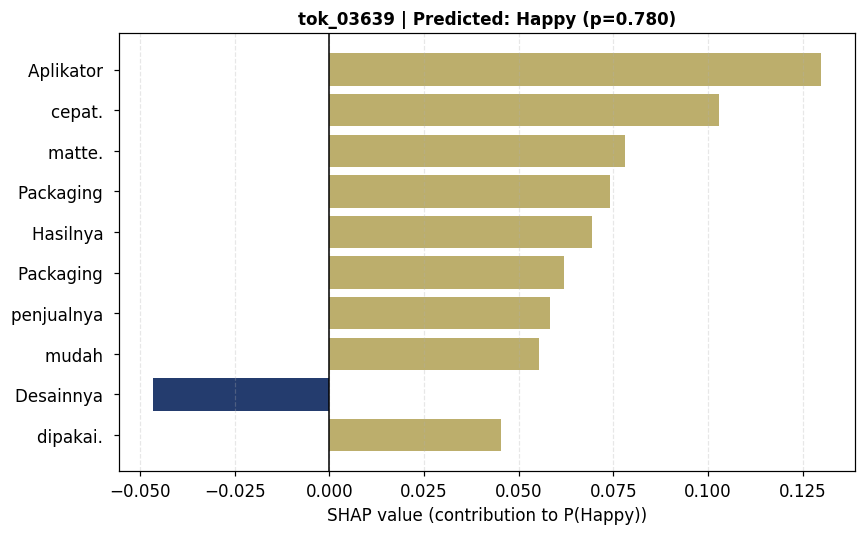

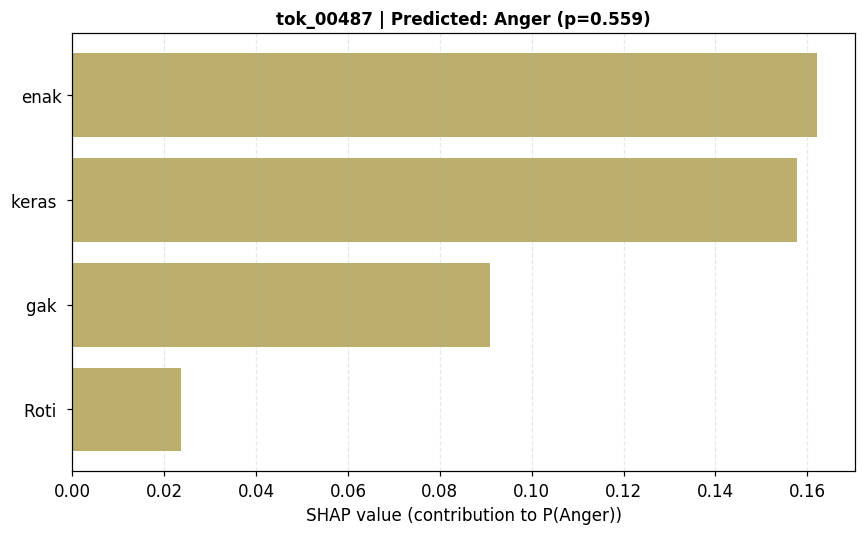

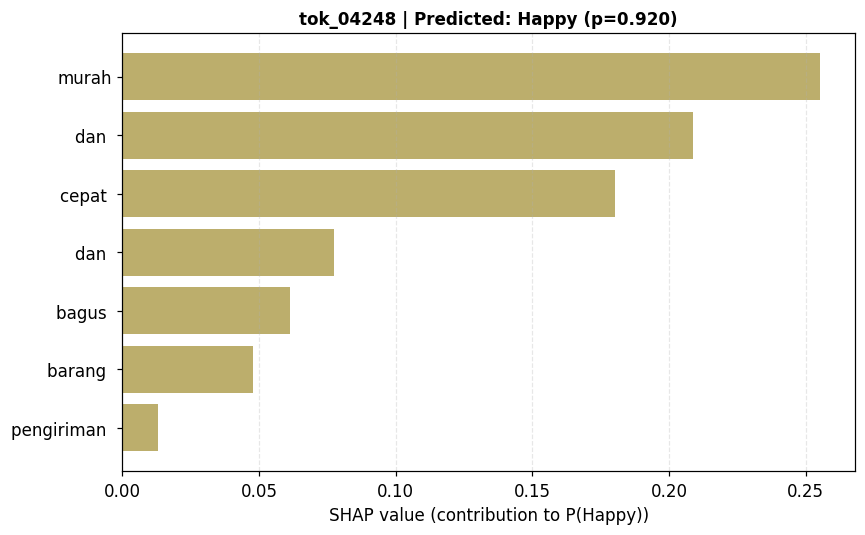

Gambar SHAP disimpan (PNG 600 dpi + PDF) di /kaggle/working/outputs/figures


In [10]:
# ============================================================
# SHAP TOKEN-LEVEL EXPLANATION
# ============================================================
try:
    import shap
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"], check=False)
    import shap


@torch.no_grad()
def embed_texts(texts, batch_size=BATCH_SIZE):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t) for t in texts[i:i + batch_size]]
        enc = xlmr_tok(batch, padding=True, truncation=True,
                       max_length=MAX_LEN, return_tensors="pt").to(device)
        h = xlmr_mod(**enc).last_hidden_state
        m = enc["attention_mask"].unsqueeze(-1).float()
        out.append(((h * m).sum(1) / m.sum(1).clamp(min=1e-9)).cpu().numpy())
    return np.vstack(out)


def predict_texts(texts, class_idx=None):
    """teks -> probabilitas terkalibrasi. Batched. Rantai penuh."""
    texts = [str(t) for t in np.atleast_1d(np.asarray(texts, dtype=object))]
    Z = transform_ref(embed_texts(texts))
    px = xgb_ref.predict_proba(Z) if xgb_ref is not None else None
    pl = lr_ref.predict_proba(Z) if lr_ref is not None else None
    proba = blend(px, pl, W_REF) * ALPHA_REF
    proba = proba / proba.sum(axis=1, keepdims=True)
    return proba if class_idx is None else proba[:, class_idx]


masker = shap.maskers.Text(r"\W+")


def explain_text(text, class_idx, max_evals=SHAP_MAX_EVALS):
    n_tok = len(re.findall(r"\S+", str(text)))
    budget = max(max_evals, 2 * n_tok + 2)
    ex = shap.Explainer(lambda x: predict_texts(x, class_idx), masker)
    try:
        return ex([text], max_evals=budget)[0]
    except TypeError:
        return shap.Explainer(lambda x: predict_texts(x, class_idx),
                              masker, max_evals=budget)([text])[0]


rng0 = np.random.default_rng(SEED_PRIMARY)
show_idx = rng0.choice(ART["test_idx"], size=min(3, len(ART["test_idx"])), replace=False)

for k, gi in enumerate(show_idx):
    text = str(df[TEXT_COL].iloc[gi])
    probs = predict_texts([text])[0]
    ci = int(np.argmax(probs))
    sv = explain_text(text, ci)

    toks = [(w, v) for w, v in zip(sv.data, sv.values) if str(w).strip()]
    toks = sorted(toks, key=lambda t: abs(t[1]), reverse=True)[:10][::-1]
    words, vals = [t[0] for t in toks], [t[1] for t in toks]

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = [plt.cm.cividis(0.75) if v > 0 else plt.cm.cividis(0.15) for v in vals]
    ax.barh(range(len(words)), vals, color=colors)
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel(f"SHAP value (contribution to P({CLASSES[ci]}))")
    ax.set_title(f"{df['uid'].iloc[gi]} | Predicted: {CLASSES[ci]} (p={probs[ci]:.3f})",
                 fontweight="bold", fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    fig.tight_layout()
    savefig(fig, f"shap_tokopedia_{k+1}")
    plt.show()

print("Gambar SHAP disimpan (PNG 600 dpi + PDF) di", FIG_DIR)

## 9. Uji faithfulness SHAP — deletion / insertion + AOPC

Unit perturbasi adalah token milik SHAP sendiri (`sv.data`), karena text masker menjamin
`"".join(sv.data)` sama persis dengan teks asli — tidak ada masalah alignment.

faithfulness:   0%|          | 0/30 [00:00<?, ?it/s]

(3 sampel dilewati: teks terlalu pendek atau explainer gagal)

TABEL 5 — SHAP FAITHFULNESS (27 sampel test, top-5 token)
                          metric    SHAP ranking  Random ranking  mean_diff  p_value  significant_0.05
 AOPC deletion (higher = better) 0.2245 ± 0.2066 0.1095 ± 0.1976     0.1150   0.0006              True
AOPC insertion (higher = better) 0.3454 ± 0.2212 0.1197 ± 0.2245     0.2257   0.0001              True


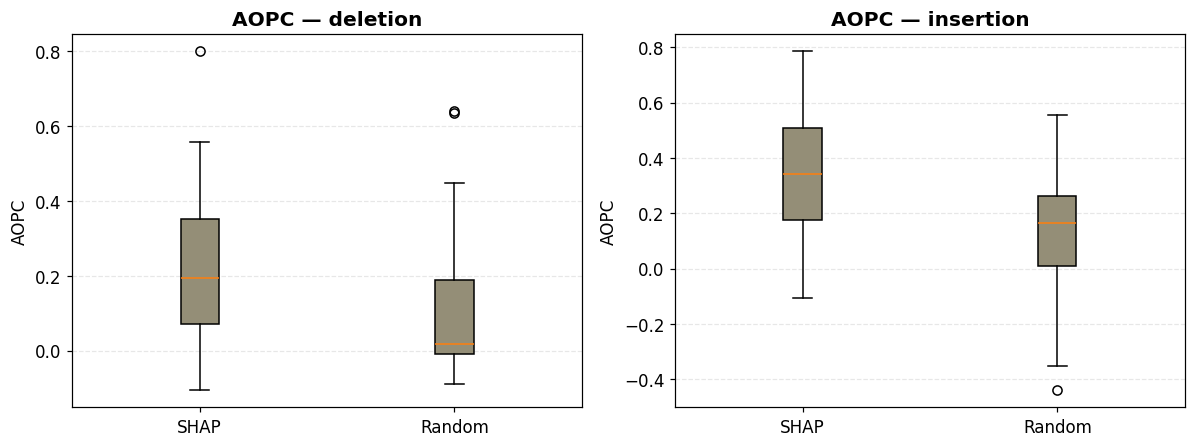

In [11]:
# ============================================================
# FAITHFULNESS: DELETION / INSERTION / AOPC
# ============================================================
def perturb_curve(tokens, ranking, k_max, mode, class_idx):
    variants = []
    for k in range(0, k_max + 1):
        chosen = set(ranking[:k])
        if mode == "deletion":
            parts = ["" if i in chosen else t for i, t in enumerate(tokens)]
        else:
            parts = [t if i in chosen else "" for i, t in enumerate(tokens)]
        variants.append("".join(parts))
    return predict_texts(variants, class_idx)


def aopc(scores, mode):
    if mode == "deletion":
        return float(np.mean([scores[0] - s for s in scores[1:]]))
    return float(np.mean([s - scores[0] for s in scores[1:]]))


if RUN_FAITHFUL:
    rng = np.random.default_rng(SEED_PRIMARY)
    K_MAX = 5
    pool = list(rng.permutation(ART["test_idx"]))[:N_FAITHFUL]

    rows, skipped = [], 0
    for gi in tqdm(pool, desc="faithfulness"):
        text = str(df[TEXT_COL].iloc[gi])
        probs = predict_texts([text])[0]
        ci = int(np.argmax(probs))
        try:
            sv = explain_text(text, ci)
        except Exception:
            skipped += 1; continue

        tokens = [str(t) for t in sv.data]
        vals = np.asarray(sv.values, dtype=float).ravel()
        content = [i for i, t in enumerate(tokens) if t.strip() and i < len(vals)]
        if len(content) < 3:
            skipped += 1; continue

        shap_rank = sorted(content, key=lambda i: -abs(vals[i]))
        rand_rank = list(rng.permutation(content))
        k = min(K_MAX, len(content) - 1)

        rec = {"uid": df["uid"].iloc[gi], "predicted": CLASSES[ci], "n_tokens": len(content)}
        for mode in ("deletion", "insertion"):
            rec[f"aopc_{mode}_shap"] = aopc(perturb_curve(tokens, shap_rank, k, mode, ci), mode)
            rec[f"aopc_{mode}_random"] = aopc(perturb_curve(tokens, rand_rank, k, mode, ci), mode)
        rows.append(rec)

    df_faith = pd.DataFrame(rows)
    df_faith.to_csv(os.path.join(OUT_DIR, "raw_faithfulness_per_sample.csv"), index=False)
    if skipped:
        print(f"({skipped} sampel dilewati: teks terlalu pendek atau explainer gagal)")

    print("\n" + "=" * 82)
    print(f"TABEL 5 — SHAP FAITHFULNESS ({len(df_faith)} sampel test, top-{K_MAX} token)")
    print("=" * 82)
    summ = []
    for mode in ("deletion", "insertion"):
        a = df_faith[f"aopc_{mode}_shap"].values
        b = df_faith[f"aopc_{mode}_random"].values
        try:
            _, p = stats.wilcoxon(a, b)
        except Exception:
            p = np.nan
        summ.append({"metric": f"AOPC {mode} (higher = better)",
                     "SHAP ranking": f"{a.mean():.4f} ± {a.std(ddof=1):.4f}",
                     "Random ranking": f"{b.mean():.4f} ± {b.std(ddof=1):.4f}",
                     "mean_diff": a.mean() - b.mean(), "p_value": p,
                     "significant_0.05": (p < 0.05) if p == p else False})
    faith_tbl = pd.DataFrame(summ)
    print(faith_tbl.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    faith_tbl.to_csv(os.path.join(OUT_DIR, "table5_shap_faithfulness.csv"), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, mode in zip(axes, ("deletion", "insertion")):
        ax.boxplot([df_faith[f"aopc_{mode}_shap"], df_faith[f"aopc_{mode}_random"]],
                   patch_artist=True, boxprops=dict(facecolor=plt.cm.cividis(0.6)))
        ax.set_xticks([1, 2]); ax.set_xticklabels(["SHAP", "Random"])
        ax.set_title(f"AOPC — {mode}", fontweight="bold"); ax.set_ylabel("AOPC")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout(); savefig(fig, "shap_faithfulness_aopc"); plt.show()
else:
    print("RUN_FAITHFUL = False -> dilewati")

## 10. Analisis waktu komputasi — boundary dipisah

Reviewer 1 #8 menghitung sendiri bahwa ME-XBAL sekitar 3.37× lebih lambat dari XLM-R Hybrid dan
3.90× dari IndoBERT Hybrid saat training pada Tokopedia. Tabel di bawah memisahkan tiap komponen
biaya sehingga manuskrip dapat membedakan efisiensi training, efisiensi inference, dan biaya
menghasilkan penjelasan — bukan menyajikannya sebagai satu keunggulan tunggal.

warmup:   0%|          | 0/1 [00:00<?, ?it/s]

timing/xlmr:   0%|          | 0/34 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

warmup:   0%|          | 0/1 [00:00<?, ?it/s]

timing/indo:   0%|          | 0/34 [00:00<?, ?it/s]

TABEL 6 — BIAYA KOMPUTASI (test set n=1081, inference 20x run)
          Model  Embedding extraction (s)  Preprocessing fit (s)  Classifier training (s)  Weight + calibration (s)  Total training (s)  Classifier inference (s)  Inference sd (s)  Inference per sample (ms)  End-to-end inference per sample (ms)
        ME-XBAL                  4.522526               0.426681                 4.838292                  1.304827            6.569800                  0.001308          0.000096                   0.001210                              4.184861
    ME-XBAL+XGB                  4.522526               0.469870                12.349922                  1.345661           14.165454                  0.016829          0.004359                   0.015568                              4.199219
   XLM-R Hybrid                  4.522526               0.462726                20.697175                  1.320487           22.480387                  0.023868          0.005826                   0.02

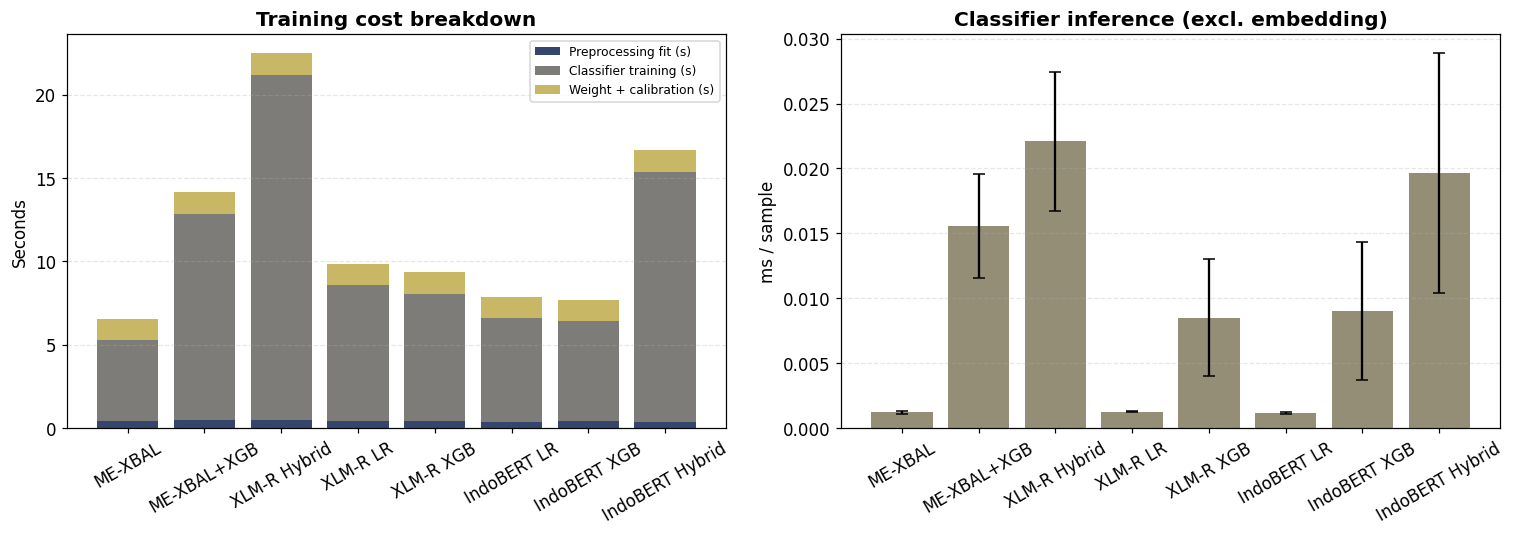

In [12]:
# ============================================================
# TIMING — BOUNDARY DIPISAH
# ============================================================
if RUN_TIMING:
    tr, va, te = SPLITS[SEED_PRIMARY]
    texts_te = df[TEXT_COL].iloc[te].tolist()
    n_te = len(te)

    embed_cost = {}
    for key, name in ENCODERS.items():
        tok, mod = (xlmr_tok, xlmr_mod) if key == "xlmr" else load_encoder(name)
        _ = encode_texts(texts_te[:8], tok, mod, desc="warmup")
        t0 = time.perf_counter()
        _ = encode_texts(texts_te, tok, mod, desc=f"timing/{key}")
        embed_cost[key] = time.perf_counter() - t0
        if key != "xlmr":
            del mod; torch.cuda.empty_cache()

    rows = []
    for cfg in VARIANTS:
        set_seed(SEED_PRIMARY)
        X = EMB[cfg["encoder"]]

        t0 = time.perf_counter()
        transform, _, _ = build_preprocessor(X[tr], cfg["scale"], cfg["do_pca"], SEED_PRIMARY)
        X_tr = transform(X[tr])
        t_pre = time.perf_counter() - t0

        t0 = time.perf_counter()
        xm, lm = train_classifiers(X_tr, y_all[tr], cfg, SEED_PRIMARY)
        t_train = time.perf_counter() - t0

        X_va = transform(X[va])
        t0 = time.perf_counter()
        px_va = xm.predict_proba(X_va) if cfg["use_xgb"] else None
        pl_va = lm.predict_proba(X_va) if cfg["use_lr"] else None
        if cfg["use_xgb"] and cfg["use_lr"]:
            w = tune_weight(px_va, pl_va, y_all[va]) if cfg["tune_w"] else cfg["w_xgb"]
        else:
            w = 1.0 if cfg["use_xgb"] else 0.0
        alpha = tune_alpha(blend(px_va, pl_va, w), y_all[va]) if cfg["calibrate"] \
            else np.ones(N_CLASSES)
        t_cal = time.perf_counter() - t0

        X_te = transform(X[te])
        for _ in range(2):
            _ = blend(xm.predict_proba(X_te) if cfg["use_xgb"] else None,
                      lm.predict_proba(X_te) if cfg["use_lr"] else None, w)
        times = []
        for _ in range(20):
            t0 = time.perf_counter()
            p = blend(xm.predict_proba(X_te) if cfg["use_xgb"] else None,
                      lm.predict_proba(X_te) if cfg["use_lr"] else None, w)
            _ = np.argmax(p * alpha, axis=1)
            times.append(time.perf_counter() - t0)

        rows.append({
            "Model": cfg["name"],
            "Embedding extraction (s)": embed_cost[cfg["encoder"]],
            "Preprocessing fit (s)": t_pre,
            "Classifier training (s)": t_train,
            "Weight + calibration (s)": t_cal,
            "Total training (s)": t_pre + t_train + t_cal,
            "Classifier inference (s)": float(np.mean(times)),
            "Inference sd (s)": float(np.std(times, ddof=1)),
            "Inference per sample (ms)": 1000 * float(np.mean(times)) / n_te,
            "End-to-end inference per sample (ms)":
                1000 * (float(np.mean(times)) + embed_cost[cfg["encoder"]]) / n_te,
        })

    df_time = pd.DataFrame(rows).set_index("Model").loc[VARIANT_ORDER].reset_index()

    try:
        sample_text = str(df[TEXT_COL].iloc[te[0]])
        ci = int(np.argmax(predict_texts([sample_text])[0]))
        t0 = time.perf_counter()
        _ = explain_text(sample_text, ci)
        shap_cost = time.perf_counter() - t0
    except Exception as e:
        print("SHAP timing dilewati:", e)
        shap_cost = float("nan")

    print("=" * 104)
    print(f"TABEL 6 — BIAYA KOMPUTASI (test set n={n_te}, inference 20x run)")
    print("=" * 104)
    print(df_time.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    print(f"\nBiaya penjelasan SHAP (ME-XBAL): {shap_cost:.3f} s/sampel")

    ref = df_time[df_time["Model"] == MEXBAL_NAME]["Total training (s)"].iloc[0]
    fastest = df_time.loc[df_time["Total training (s)"].idxmin()]
    print(f"\nME-XBAL {ref:.2f} s vs tercepat ({fastest['Model']}) {fastest['Total training (s)']:.2f} s "
          f"-> {ref/fastest['Total training (s)']:.2f}x lebih lambat saat training.")
    print("Namun end-to-end per sampel hampir sama untuk semua varian karena ekstraksi")
    print("embedding mendominasi. Klaim yang boleh dibuat adalah TRADE-OFF performa-efisiensi.")

    # Biaya SHAP diukur pada MODEL REFERENSI, jadi atribusinya harus mengikuti
    # MEXBAL_NAME, bukan string "ME-XBAL" yang kini menunjuk varian ringan.
    df_time["SHAP cost per sample (s)"] = [shap_cost if m == MEXBAL_NAME else np.nan
                                           for m in df_time["Model"]]
    df_time.to_csv(os.path.join(OUT_DIR, "table6_computational_cost.csv"), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    comp = ["Preprocessing fit (s)", "Classifier training (s)", "Weight + calibration (s)"]
    bottom = np.zeros(len(df_time))
    for j, c in enumerate(comp):
        axes[0].bar(df_time["Model"], df_time[c], bottom=bottom, label=c,
                    color=plt.cm.cividis(0.2 + 0.3 * j))
        bottom += df_time[c].values
    axes[0].set_ylabel("Seconds"); axes[0].set_title("Training cost breakdown", fontweight="bold")
    axes[0].tick_params(axis="x", rotation=30); axes[0].legend(fontsize=8)
    axes[1].bar(df_time["Model"], df_time["Inference per sample (ms)"],
                yerr=1000 * df_time["Inference sd (s)"] / n_te, capsize=4,
                color=plt.cm.cividis(0.6))
    axes[1].set_ylabel("ms / sample")
    axes[1].set_title("Classifier inference (excl. embedding)", fontweight="bold")
    axes[1].tick_params(axis="x", rotation=30)
    for ax in axes:
        ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout(); savefig(fig, "computational_cost"); plt.show()
else:
    print("RUN_TIMING = False -> dilewati")

## 11. Pembanding di luar frozen embedding — fine-tuned XLM-R (opsional)

In [13]:
# ============================================================
# BASELINE: FINE-TUNED XLM-R (SINGLE-LABEL)
# ============================================================
if RUN_FINETUNE:
    from torch.utils.data import Dataset, DataLoader
    from transformers import AutoModelForSequenceClassification

    FT_LR, FT_BS = 2e-5, 16

    class TxtDataset(Dataset):
        def __init__(self, texts, labels, tok):
            self.enc = tok([str(t) for t in texts], padding="max_length", truncation=True,
                           max_length=MAX_LEN, return_tensors="pt")
            self.labels = torch.tensor(labels, dtype=torch.long)
        def __len__(self): return len(self.labels)
        def __getitem__(self, i):
            item = {k: v[i] for k, v in self.enc.items()}
            item["labels"] = self.labels[i]
            return item

    @torch.no_grad()
    def ft_predict(model, texts, tok):
        model.eval(); out = []
        for i in range(0, len(texts), 32):
            enc = tok([str(t) for t in texts[i:i+32]], padding=True, truncation=True,
                      max_length=MAX_LEN, return_tensors="pt").to(device)
            out.append(torch.softmax(model(**enc).logits, dim=-1).cpu().numpy())
        return np.vstack(out)

    ft_records = []
    for seed in FT_SEEDS:
        set_seed(seed)
        tok = AutoTokenizer.from_pretrained(XLMR_NAME)
        model_ft = AutoModelForSequenceClassification.from_pretrained(
            XLMR_NAME, num_labels=N_CLASSES).to(device)

        tr, va, te = SPLITS[seed]
        dl = DataLoader(TxtDataset(df[TEXT_COL].iloc[tr].tolist(), y_all[tr], tok),
                        batch_size=FT_BS, shuffle=True)
        opt = torch.optim.AdamW(model_ft.parameters(), lr=FT_LR)

        # ------------------------------------------------------------
        # EARLY STOPPING pada Macro F1 validation. Tanpa ini, fine-tuning
        # menghasilkan variansi besar antar seed sehingga uji berpasangan
        # kehilangan daya. Perbandingan tetap adil: pipeline klasik memakai
        # train+validation lewat nested CV, fine-tuning memakai train untuk
        # melatih dan validation untuk menghentikan — data yang dilihat sama.
        # ------------------------------------------------------------
        val_texts = df[TEXT_COL].iloc[va].tolist()

        # ------------------------------------------------------------
        # WALL-CLOCK FINE-TUNING
        #
        # Boundary training fine-tuning = seluruh loop epoch termasuk early stopping,
        # TIDAK termasuk pemuatan tokenizer/checkpoint. Ini tidak identik dengan
        # boundary "total train" pipeline beku (preprocessing + classifier + threshold,
        # dengan ekstraksi embedding dilaporkan terpisah), karena fine-tuning tidak
        # memiliki tahap embedding yang terpisah. Perbedaan boundary ini harus
        # dinyatakan di catatan tabel manuskrip, bukan disembunyikan.
        #
        # Inference diukur pada seluruh test set setelah warm-up, dilaporkan per sampel.
        # ------------------------------------------------------------
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t_train0 = time.perf_counter()

        best_f1, best_state, patience_left = -1.0, None, FT_PATIENCE
        for ep in range(FT_MAX_EPOCHS):
            model_ft.train()
            tot = 0.0
            for batch in tqdm(dl, desc=f"FT seed={seed} ep{ep+1}/{FT_MAX_EPOCHS}", leave=False):
                batch = {k: v.to(device) for k, v in batch.items()}
                opt.zero_grad(); loss = model_ft(**batch).loss
                loss.backward(); opt.step(); tot += loss.item()

            pv_ep = ft_predict(model_ft, val_texts, tok)
            a_ep = tune_alpha(pv_ep, y_all[va])
            f1_val = f1_score(y_all[va], np.argmax(pv_ep * a_ep, axis=1),
                              average="macro", zero_division=0)
            print(f"  seed={seed} epoch {ep+1}: loss {tot/len(dl):.4f}  val macro F1 {f1_val:.4f}")

            if f1_val > best_f1 + 1e-6:
                best_f1 = f1_val
                best_state = {k: v.detach().cpu().clone()
                              for k, v in model_ft.state_dict().items()}
                patience_left = FT_PATIENCE
            else:
                patience_left -= 1
                if patience_left <= 0:
                    print(f"  seed={seed}: early stop di epoch {ep+1} "
                          f"(val macro F1 terbaik {best_f1:.4f})")
                    break

        if best_state is not None:
            model_ft.load_state_dict(best_state)

        if torch.cuda.is_available(): torch.cuda.synchronize()
        ft_train_time = time.perf_counter() - t_train0

        pv = ft_predict(model_ft, val_texts, tok)
        alpha = tune_alpha(pv, y_all[va])
        pt = ft_predict(model_ft, df[TEXT_COL].iloc[te].tolist(), tok)
        pred = np.argmax(pt * alpha, axis=1)

        texts_te_all = df[TEXT_COL].iloc[te].tolist()
        _ = ft_predict(model_ft, texts_te_all[:8], tok)              # warm-up
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t_inf0 = time.perf_counter()
        _ = ft_predict(model_ft, texts_te_all, tok)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        ft_infer_ms = (time.perf_counter() - t_inf0) / len(texts_te_all) * 1000
        print(f"  seed={seed} biaya: train {ft_train_time:.1f}s | "
              f"inference {ft_infer_ms:.4f} ms/sampel")

        ft_records.append({"cfg": "XLM-R fine-tuned", "seed": seed,
                           "train_time_s": ft_train_time,
                           "infer_ms_per_sample": ft_infer_ms,
                           "macro_f1": f1_score(y_all[te], pred, average="macro", zero_division=0),
                           "micro_f1": f1_score(y_all[te], pred, average="micro", zero_division=0),
                           "accuracy": accuracy_score(y_all[te], pred)})
        print(f"  seed={seed} -> Macro F1 {ft_records[-1]['macro_f1']:.4f}")
        del model_ft; torch.cuda.empty_cache()

    df_ft = pd.DataFrame(ft_records)
    df_ft.to_csv(os.path.join(OUT_DIR, "raw_results_finetuned_xlmr.csv"), index=False)

    sub = df_main[(df_main["cfg"] == "ME-XBAL") & (df_main["seed"].isin(FT_SEEDS))]
    sub_xgb = df_main[(df_main["cfg"] == "ME-XBAL+XGB") & (df_main["seed"].isin(FT_SEEDS))]
    comp = pd.concat([sub[["cfg", "seed"] + metric_cols],
                      sub_xgb[["cfg", "seed"] + metric_cols],
                      df_ft[["cfg", "seed"] + metric_cols]])
    summ_ft = summarize(comp, metric_cols)

    ft_rows = []
    b = df_ft.sort_values("seed")["macro_f1"].values
    for name, frame in [("ME-XBAL", sub), ("ME-XBAL+XGB", sub_xgb)]:
        a_ = frame.sort_values("seed")["macro_f1"].values
        try:
            _, p_ = stats.wilcoxon(a_, b)
        except Exception:
            p_ = np.nan
        pooled = np.sqrt((a_.var(ddof=1) + b.var(ddof=1)) / 2)
        ft_rows.append({"comparison": f"{name} vs XLM-R fine-tuned",
                        "mean_diff": a_.mean() - b.mean(),
                        "cohens_d": (a_.mean() - b.mean()) / pooled if pooled > 0 else np.nan,
                        "wins_per_seed": f"{int((a_ > b).sum())}/{len(a_)}",
                        "p_value": p_,
                        "significant_0.05": (p_ < 0.05) if p_ == p_ else False})
    ft_sig = pd.DataFrame(ft_rows)
    ft_sig.to_csv(os.path.join(OUT_DIR, "table7b_finetuned_significance.csv"), index=False)
    a = sub.sort_values("seed")["macro_f1"].values
    p_ft = ft_sig.iloc[0]["p_value"]

    print("\n" + "=" * 78)
    print(f"TABEL 7 — PEMBANDING FINE-TUNED (mean ± std atas {len(FT_SEEDS)} seed)")
    print("=" * 78)
    v = summ_ft[["cfg", "macro_f1_str", "micro_f1_str", "accuracy_str"]]
    v.columns = ["Model", "Macro F1", "Micro F1", "Accuracy"]
    print(v.to_string(index=False))
    print("\nUJI SIGNIFIKANSI vs FINE-TUNED (Wilcoxon berpasangan atas seed)")
    print(ft_sig.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    if len(FT_SEEDS) < 6:
        print(f"\nPERINGATAN: hanya {len(FT_SEEDS)} seed — p minimum Wilcoxon = 0.25 untuk n=3.")
    summ_ft.to_csv(os.path.join(OUT_DIR, "table7_finetuned_comparison.csv"), index=False)
else:
    print("RUN_FINETUNE = False -> dilewati")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FT seed=42 ep1/8:   0%|          | 0/220 [00:00<?, ?it/s]

  seed=42 epoch 1: loss 1.1759  val macro F1 0.5919


FT seed=42 ep2/8:   0%|          | 0/220 [00:00<?, ?it/s]

...

  seed=606 epoch 5: loss 0.5422  val macro F1 0.6802


FT seed=606 ep6/8:   0%|          | 0/220 [00:00<?, ?it/s]

  seed=606 epoch 6: loss 0.4679  val macro F1 0.6792


FT seed=606 ep7/8:   0%|          | 0/220 [00:00<?, ?it/s]

  seed=606 epoch 7: loss 0.3774  val macro F1 0.6726
  seed=606: early stop di epoch 7 (val macro F1 terbaik 0.6913)
  seed=606 biaya: train 663.4s | inference 4.8906 ms/sampel
  seed=606 -> Macro F1 0.6912

TABEL 7 — PEMBANDING FINE-TUNED (mean ± std atas 10 seed)
           Model        Macro F1        Micro F1        Accuracy
         ME-XBAL 0.5984 ± 0.0136 0.6247 ± 0.0126 0.6247 ± 0.0126
     ME-XBAL+XGB 0.6066 ± 0.0144 0.6328 ± 0.0128 0.6328 ± 0.0128
XLM-R fine-tuned 0.6776 ± 0.0139 0.7055 ± 0.0152 0.7055 ± 0.0152

UJI SIGNIFIKANSI vs FINE-TUNED (Wilcoxon berpasangan atas seed)
                     comparison  mean_diff  cohens_d wins_per_seed  p_value  significant_0.05
    ME-XBAL vs XLM-R fine-tuned    -0.0792   -5.7723          0/10   0.0020              True
ME-XBAL+XGB vs XLM-R fine-tuned    -0.0710   -5.0325          0/10   0.0020              True


## 11b. Biaya wall-clock fine-tuning


In [14]:
# ============================================================
# BIAYA FINE-TUNING vs PIPELINE BEKU
#
# Angka inilah yang menopang argumen trade-off di manuskrip: pada SemEval
# ME-XBAL menang skor DAN jauh lebih murah; pada Tokopedia ME-XBAL kalah skor,
# sehingga selisih biaya menjadi satu-satunya penyeimbang yang tersisa.
# Tanpa angka ini, kekalahan di Tokopedia berdiri tanpa pembanding.
# ============================================================
if RUN_FINETUNE and len(ft_records):
    cost_ft = pd.DataFrame([{"seed": r["seed"],
                             "train_time_s": r.get("train_time_s", np.nan),
                             "infer_ms_per_sample": r.get("infer_ms_per_sample", np.nan)}
                            for r in ft_records])
    summary_ft_cost = pd.DataFrame([{
        "model": "XLM-R fine-tuned (end-to-end)",
        "train_time_s_mean": cost_ft["train_time_s"].mean(),
        "train_time_s_std":  cost_ft["train_time_s"].std(ddof=1),
        "infer_ms_per_sample_mean": cost_ft["infer_ms_per_sample"].mean(),
        "n_seeds": len(cost_ft),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    }])
    cost_ft.to_csv(os.path.join(OUT_DIR, "raw_finetuned_cost_per_seed.csv"), index=False)
    summary_ft_cost.to_csv(os.path.join(OUT_DIR, "table_finetuned_cost.csv"), index=False)

    print("=" * 74)
    print("BIAYA FINE-TUNING XLM-R")
    print("=" * 74)
    print(summary_ft_cost.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

    try:
        mex_total = float(df_time.loc[df_time["Model"] == MEXBAL_NAME,
                                      "Total training (s)"].iloc[0])
        ratio = summary_ft_cost["train_time_s_mean"].iloc[0] / mex_total
        print(f"\n{MEXBAL_NAME} total train : {mex_total:.2f} s")
        print(f"Fine-tuning lebih lambat  : {ratio:.1f}x")
    except Exception as e:
        print(f"\n(Rasio terhadap ME-XBAL dilewati: {type(e).__name__} — "
              "cocokkan nama kolom tabel timing bila perlu.)")
else:
    print("RUN_FINETUNE = False atau ft_records kosong -> dilewati")


BIAYA FINE-TUNING XLM-R
                        model  train_time_s_mean  train_time_s_std  infer_ms_per_sample_mean  n_seeds      gpu
XLM-R fine-tuned (end-to-end)            727.815            45.406                     4.654       10 Tesla T4

ME-XBAL+XGB total train : 14.17 s
Fine-tuning lebih lambat  : 51.4x


## 12. Gambar & ekspor akhir

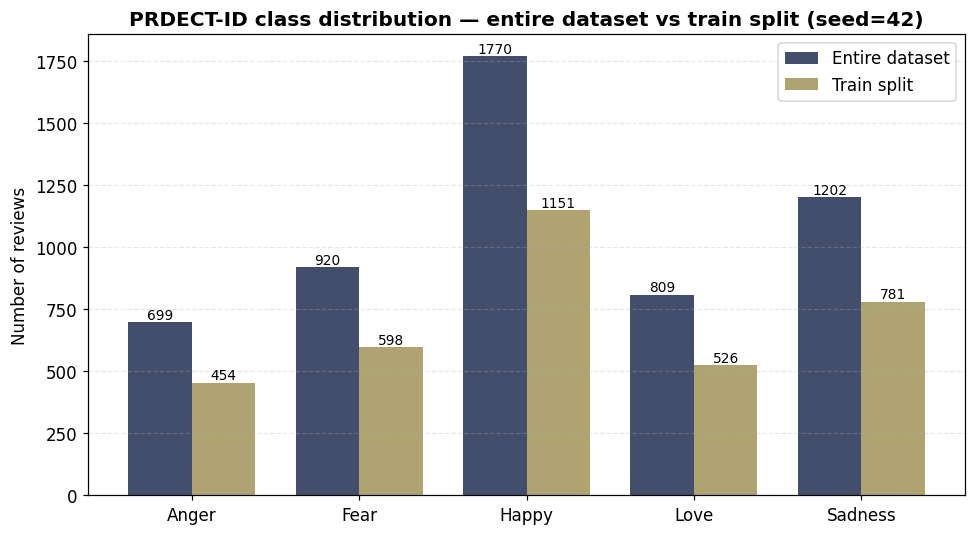

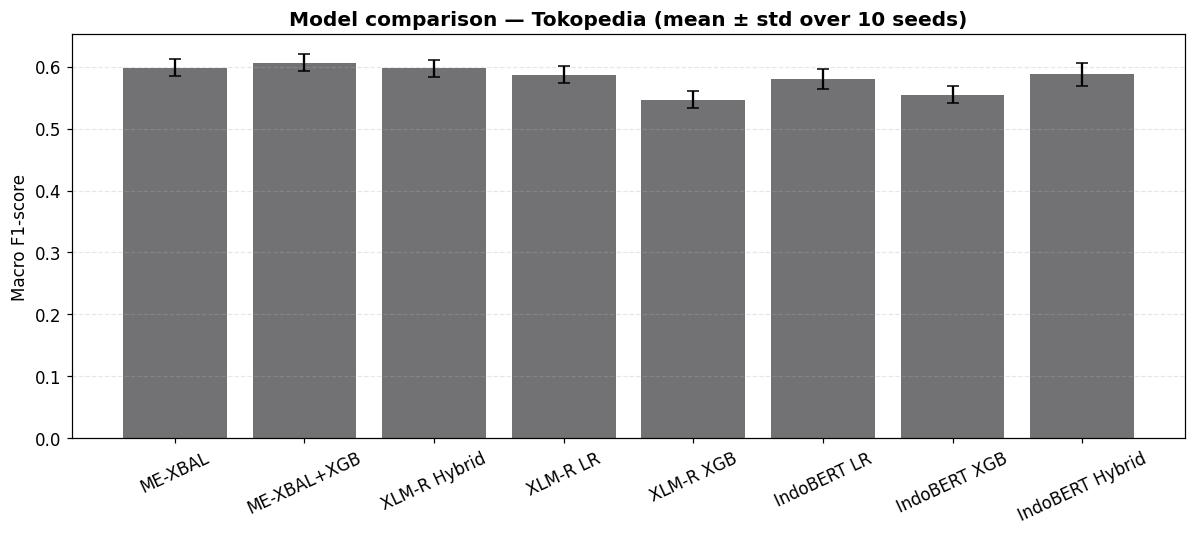

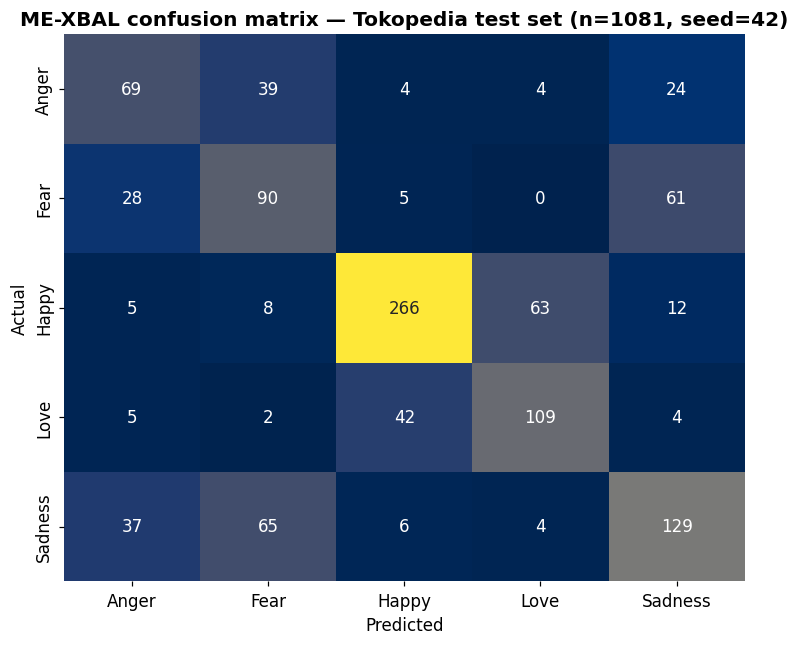

TABEL KONFIGURASI (Appendix)
                    Item                                                                                                                                                                                                                                                       Value
                 Dataset                                                                                                                                                                                                             PRDECT-ID Dataset.csv — 5400 reviews, 5 classes
      Encoder (proposed)                                                                                                                                                                                                xlm-roberta-base — frozen, cached embeddings, no fine-tuning
      Encoder (baseline)                                                                                                                    

In [15]:
# ============================================================
# GAMBAR & EKSPOR
# ============================================================
# --- distribusi kelas: seluruh dataset vs train split ---
d = dist[dist["Emotion"] != "TOTAL"]
x = np.arange(len(d)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, d["Entire dataset"], w, label="Entire dataset", color=plt.cm.cividis(0.25))
ax.bar(x + w/2, d["Train split"], w, label="Train split", color=plt.cm.cividis(0.7))
for i, (a_, b_) in enumerate(zip(d["Entire dataset"], d["Train split"])):
    ax.text(i - w/2, a_ + 12, str(a_), ha="center", fontsize=9)
    ax.text(i + w/2, b_ + 12, str(b_), ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(d["Emotion"])
ax.set_ylabel("Number of reviews")
ax.set_title(f"PRDECT-ID class distribution — entire dataset vs train split (seed={SEED_PRIMARY})",
             fontweight="bold")
ax.legend(); ax.grid(axis="y", linestyle="--", alpha=0.3)
fig.tight_layout(); savefig(fig, "class_distribution"); plt.show()

# --- perbandingan model dengan error bar ---
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(summary["cfg"], summary["macro_f1_mean"], yerr=summary["macro_f1_std"],
       capsize=4, color=plt.cm.cividis(0.45))
ax.set_ylabel("Macro F1-score")
ax.set_title(f"Model comparison — Tokopedia (mean ± std over {len(SEEDS)} seeds)",
             fontweight="bold")
ax.tick_params(axis="x", rotation=25); ax.grid(axis="y", linestyle="--", alpha=0.3)
fig.tight_layout(); savefig(fig, "model_comparison"); plt.show()

# --- confusion matrix 5x5 ---
cm = confusion_matrix(ART["y_true"], ART["y_pred"], labels=np.arange(N_CLASSES))
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="cividis", cbar=False,
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"ME-XBAL confusion matrix — Tokopedia test set "
             f"(n={len(ART['y_true'])}, seed={SEED_PRIMARY})", fontweight="bold")
fig.tight_layout(); savefig(fig, "confusion_matrix"); plt.show()

# --- tabel konfigurasi ---
import sklearn, transformers
try:
    import shap as _shap; shap_ver = _shap.__version__
except Exception:
    shap_ver = "n/a"

config_table = pd.DataFrame([
    ("Dataset", os.path.basename(TOKOPEDIA_CSV) + f" — {len(df)} reviews, {N_CLASSES} classes"),
    ("Encoder (proposed)", XLMR_NAME + " — frozen, cached embeddings, no fine-tuning"),
    ("Encoder (baseline)", INDOBERT_NAME + " — frozen, own scaler/PCA"),
    ("Sentence pooling", "masked mean pooling over last_hidden_state"),
    ("Max sequence length", str(MAX_LEN)),
    ("Dimensionality reduction", "PCA n_components=0.95 (fit on train only)"),
    ("Feature scaling", "StandardScaler (fit on train only)"),
    ("XGBoost", json.dumps(XGB_PARAMS)),
    ("Cost sensitivity", "compute_sample_weight('balanced') on train only"),
    ("Logistic Regression", "C=0.1, L2, lbfgs, max_iter=1000, class_weight=balanced"),
    ("Ensemble weight", "searched on validation over grid 0.00-1.00 step 0.05"),
    ("Class-prior calibration",
     f"coordinate ascent on validation, alpha in [{ALPHA_MIN}, {ALPHA_MAX}] step {ALPHA_STEP}, "
     f"{ALPHA_PASSES} passes, ties broken toward alpha=1"),
    ("Split", f"train {1-VAL_FRAC-TEST_FRAC:.2f} / val {VAL_FRAC:.2f} / test {TEST_FRAC:.2f}, "
              "StratifiedShuffleSplit"),
    ("Seeds", str(SEEDS)),
    ("Significance test", "Wilcoxon signed-rank over seeds, alpha=0.05"),
    ("SHAP", f"Partition explainer, Text masker, max_evals={SHAP_MAX_EVALS}"),
    ("Python", sys.version.split()[0]),
    ("torch", torch.__version__),
    ("transformers", transformers.__version__),
    ("scikit-learn", sklearn.__version__),
    ("xgboost", xgb.__version__),
    ("shap", shap_ver),
], columns=["Item", "Value"])
config_table.to_csv(os.path.join(OUT_DIR, "table_appendix_configuration.csv"), index=False)

print("=" * 78)
print("TABEL KONFIGURASI (Appendix)")
print("=" * 78)
print(config_table.to_string(index=False))

print("\n" + "=" * 78)
print("FILE YANG DIHASILKAN")
print("=" * 78)
for root, _, files in os.walk(OUT_DIR):
    for f in sorted(files):
        p = os.path.join(root, f)
        print(f"  {p}  ({os.path.getsize(p)/1024:.1f} KB)")

print("\nSalin angka ke manuskrip HANYA dari CSV di atas. Inkonsistensi 0.5569 vs 0.5821")
print("terjadi karena angka diambil dari dua run berbeda — sekarang hanya ada satu sumber.")